# pathMgr — a tour

**pathMgr** does symbolic path analysis: you write down a model of how variables depend on each
other, and it computes the covariance or correlation between *any* two of them — including latent
and intermediate ones — as an algebraic expression, and draws the path diagram.

It does **not** fit models to data. There is no estimation, no optimizer, no fit statistic, and no
way to hand it a dataset. Everything below is exact algebra.

### How this notebook is arranged

The package has two independent engines that compute the same covariances by different routes, and
this notebook is arranged to exploit that:

| Act | | |
|---|---|---|
| **1** | the generic core | on a model small enough that you check the machinery **by hand** |
| **2** | co-paths | a third edge type, and the mistake it exists to prevent |
| **3** | genetics | a pedigree under assortative mating, where hand-checking is hopeless |
| **4** | output | getting a figure into your own LaTeX document |

Act 1 is the one that matters. Everything after it asks you to believe results you cannot verify
yourself, so Act 1 is where you verify the thing that produces them.

In [1]:
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import Latex, Markdown, Math, display

import pathmgr as pm

# sympy expressions typeset as real LaTeX in a notebook, which is most of the reason to read this
# in notebook form. init_printing is what installs those formatters.
sp.init_printing(use_latex="mathjax")

print("sympy", sp.__version__)

sympy 1.14.0


---
## Act 1 — the generic core

The model: an exposure `x` affects an outcome `y` both **directly** and **through a mediator** `m`,
and a **latent** confounder `u` causes both `x` and `y`.

$$u \to x, \qquad x \to m \to y, \qquad x \to y, \qquad u \to y$$

Small enough to trace with a pencil, and it still has all four features that matter: a mediated
route, a direct route, a latent variable, and confounding.

### Building it: the builder API

In [2]:
m = pm.Model("confounded mediation", units=pm.Units.unstandardized())

for residual in ("V_u", "V_x", "V_m", "V_y"):
    m.declare(residual, positive=True)                 # assumptions BEFORE first use
m.add_vars("x", "m", "y")                              # observed
m.add_var("u", latent=True)                            # latent

m.add_path("u", "x", "p")      # x regresses on u with coefficient p
m.add_path("x", "m", "a")
m.add_path("m", "y", "b")
m.add_path("x", "y", "c")      # the direct effect, alongside the mediated one
m.add_path("u", "y", "q")

for name, variance in [("u", "V_u"), ("x", "V_x"), ("m", "V_m"), ("y", "V_y")]:
    m.add_variance(name, variance)

print(m.describe())

Model('confounded mediation')  [unstandardized]  rev 13
  observed (3): x, m, y
  latent   (1): u
  paths (5):
    u -> x  [p]
    x -> m  [a]
    m -> y  [b]
    x -> y  [c]
    u -> y  [q]
  covariances (4):
    u <-> u  [V_u]
    x <-> x  [V_x]
    m <-> m  [V_m]
    y <-> y  [V_y]


A `<->` self-edge is a **variance**, and on an endogenous variable it is the *residual* variance,
never the total — the model implies the total rather than stating it. So `V_x` above is the part of
`x` not explained by `u`, and $\operatorname{Var}[x] = p^2 V_u + V_x$. This catches everyone once.

### The same model in the text front-end

There are two front-ends. The text one is a thin layer over the builder — it makes builder calls
and nothing else — so anything you can build you can write, and vice versa.

In [3]:
same = pm.from_text(
    '''
    latent: u
    positive: V_u, V_x, V_m, V_y
    x ~ p*u
    m ~ a*x
    y ~ b*m + c*x + q*u
    u ~~ V_u*u
    x ~~ V_x*x
    m ~~ V_m*m
    y ~~ V_y*y
    ''',
    name="confounded mediation",
)

# ~ is a directed path, ~~ a bidirected covariance. (-- is the third kind; Act 2.)
print("same model both ways:", pm.WrightTracer(same).cov("x", "y") == pm.WrightTracer(m).cov("x", "y"))
print(same.to_text())

same model both ways: True
# confounded mediation
units: unstandardized
latent: u
positive: V_m, V_u, V_x, V_y

x ~ p*u
m ~ a*x
y ~ b*m + c*x + q*u

u ~~ V_u*u
x ~~ V_x*x
m ~~ V_m*m
y ~~ V_y*y



### The diagram

Latent variables are ellipses, observed ones rectangles. Rendering is a separate layer that never
touches the computation path — and it is the reason this package exists rather than a dozen lines
of matrix algebra.

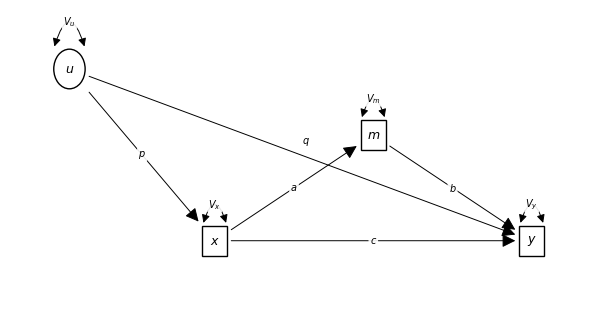

In [4]:
from pathmgr.render import DiagramStyle, Layout
from pathmgr.render.raster import draw_on_axes

layout = Layout({"u": (-1.6, 2.6), "x": (0.6, 0.0), "m": (3.0, 1.6), "y": (5.4, 0.0)})

fig, ax = plt.subplots(figsize=(7.5, 4.2))
draw_on_axes(m, ax, layout=layout, style=DiagramStyle())
plt.show()

### Asking a question

`RAMEngine` computes every covariance at once, in closed form, from the **Reticular Action Model**:

$$\Sigma = F \, (I - A)^{-1} \, S \, (I - A)^{-\top} F^\top$$

Three matrices, one for each kind of thing you put in the spec:

| | | |
|---|---|---|
| $A$ | the **directed** edges | $A_{ba}$ is the coefficient of $a \to b$ — row is the *destination*, so $A$ is read "each row is a regression" |
| $S$ | the **bidirected** edges | disturbance variances on the diagonal, disturbance covariances off it |
| $F$ | the **filter** | selects the observed rows; it is the only place "latent" means anything |

**Where the formula comes from.** Every variable is the weighted sum of its parents plus its own
disturbance — that is all a directed edge asserts — so stacking the variables into a vector $v$ and
the disturbances into $\varepsilon$,

$$v = A v + \varepsilon \quad\Longrightarrow\quad (I - A)\,v = \varepsilon \quad\Longrightarrow\quad v = (I - A)^{-1}\varepsilon .$$

Take the covariance of both sides. $\operatorname{Cov}[\varepsilon]$ is exactly what $S$ records,
so $\Sigma = (I-A)^{-1} S (I-A)^{-\top}$, and $F$ merely drops the rows you cannot observe. There is
no approximation anywhere: this is an identity, not an estimator.

**The factor that matters is $(I-A)^{-1}$** — the *total-effects* matrix. Its $(i,j)$ entry is the
sum, over **every directed path** from $j$ to $i$, of the product of that path's coefficients. That
is easiest to see by expanding it as a series,

$$(I - A)^{-1} = I + A + A^2 + A^3 + \cdots$$

where $A^k$ collects the paths of exactly $k$ steps. For an acyclic model $A$ is *nilpotent* — some
power is the zero matrix, because a path cannot be longer than the graph is deep — so the series
**terminates** and the inverse is a finite, exact polynomial in the coefficients. If the model has a **cycle** the series is infinite but converges,
summing the feedback loop to its limit. That is precisely the case chain enumeration cannot handle,
and it is why this engine exists alongside the tracer.

It is also why the two engines agree rather than merely happening to match: $(I-A)^{-1}$ *is* path
enumeration, written as linear algebra. The tracer walks the paths one at a time; the engine sums
them all with a matrix inverse.

Two things worth pinning down before reading any output:

- **$S$ holds disturbances, not totals.** $S_{xx}$ is the variance of $x$'s disturbance, so
  $\Sigma_{xx}$ — the actual variance of $x$ — is generally larger. The model implies the total; you
  never state it.
- **$\Sigma$ is computed over *every* node, latent ones included.** The $F$ filtering above is a
  derived view, not something applied to the primary object, which is why `u` is an ordinary query
  target later on.

Here are those matrices for the model above.

In [5]:
A, S, F, order = m.ram()
print("row/column order:", order)   # your declaration order -- NOT sorted topologically
display(Math(r"A = " + sp.latex(A) + r"\qquad S = " + sp.latex(S)))

total_effects = sp.simplify((sp.eye(len(order)) - A).inv())
display(Math(r"(I - A)^{-1} = " + sp.latex(total_effects)))

row, column = order.index("y"), order.index("u")
display(Markdown(
    f"The rows and columns follow the order you declared the variables in, `{order}`, not a "
    "topological sort — so $A$ is not triangular here. It does not need to be: what makes the "
    "series terminate is that the graph is **acyclic**, and that makes $A$ nilpotent in any "
    f"ordering. $A^{len(order)} = 0$ is **{(A ** len(order)).is_zero_matrix}**, so the expansion "
    f"stops after {len(order)} terms.\n\n"
    f"Now read the entry of $(I-A)^{{-1}}$ in row `{order[row]}`, column `{order[column]}` — the "
    f"**total effect of $u$ on $y$**. It is ${sp.latex(total_effects[row, column])}$: exactly the "
    "sum of the three directed routes $u \\to y$, $u \\to x \\to y$ and "
    "$u \\to x \\to m \\to y$, each one the product of its coefficients. Nothing enumerated "
    "them; the inverse did."
))

row/column order: ('x', 'm', 'y', 'u')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

The rows and columns follow the order you declared the variables in, `('x', 'm', 'y', 'u')`, not a topological sort — so $A$ is not triangular here. It does not need to be: what makes the series terminate is that the graph is **acyclic**, and that makes $A$ nilpotent in any ordering. $A^4 = 0$ is **True**, so the expansion stops after 4 terms.

Now read the entry of $(I-A)^{-1}$ in row `y`, column `u` — the **total effect of $u$ on $y$**. It is $a b p + c p + q$: exactly the sum of the three directed routes $u \to y$, $u \to x \to y$ and $u \to x \to m \to y$, each one the product of its coefficients. Nothing enumerated them; the inverse did.

Note that $\Sigma$ is built **once** and cached against `model.revision`, so the first query pays
for the whole matrix and every query after it is a lookup. (For large models the engine does not
actually form that symbolic inverse — it uses topological recursions that compute the same entries
without ever expanding an $n \times n$ symbolic matrix, because the naive inverse blows up fast.
Same $\Sigma$, different route to it.)

Return an expression as the cell value rather than printing it, and it typesets:

In [6]:
engine = pm.RAMEngine(m)
engine.cov("x", "y")

        2         2                         
Vᵤ⋅a⋅b⋅p  + Vᵤ⋅c⋅p  + Vᵤ⋅p⋅q + Vₓ⋅a⋅b + Vₓ⋅c

In [7]:
# correlations too -- note it is honest about the square roots rather than assuming unit variances
engine.corr("x", "y")

                                                        2         2            ↪
                                                Vᵤ⋅a⋅b⋅p  + Vᵤ⋅c⋅p  + Vᵤ⋅p⋅q + ↪
────────────────────────────────────────────────────────────────────────────── ↪
   ____________    ___________________________________________________________ ↪
  ╱     2         ╱     2       2  2  2               2                      2 ↪
╲╱  Vᵤ⋅p  + Vₓ ⋅╲╱  Vₘ⋅b  + Vᵤ⋅a ⋅b ⋅p  + 2⋅Vᵤ⋅a⋅b⋅c⋅p  + 2⋅Vᵤ⋅a⋅b⋅p⋅q + Vᵤ⋅c  ↪

↪                                                                
↪  Vₓ⋅a⋅b + Vₓ⋅c                                                 
↪ ───────────────────────────────────────────────────────────────
↪ _______________________________________________________________
↪   2                    2       2  2                    2       
↪ ⋅p  + 2⋅Vᵤ⋅c⋅p⋅q + Vᵤ⋅q  + Vₓ⋅a ⋅b  + 2⋅Vₓ⋅a⋅b⋅c + Vₓ⋅c  + V_y 

### The part you should check yourself

The covariance above is a sum of five terms and tells you nothing about *where* they came from. The
**tracer** answers the same question by enumerating Wright chains, and returns the **decomposition**
— which is the point of the package.

Read the next output against the diagram above. Each row is one path from `x` to `y`; the `<->`
in the middle of a row is the variance the chain "turns around" on.

In [8]:
tracer = pm.WrightTracer(m)
decomposition = tracer.trace("x", "y")
print(decomposition)

Cov[x, y]  (5 chains, unstandardized)
  x <-> x -> y                 =  V_x * c
  x <- u <-> u -> y            =  p * V_u * q
  x <-> x -> m -> y            =  V_x * a * b
  x <- u <-> u -> x -> y       =  p * V_u * p * c   [revisits x]
  x <- u <-> u -> x -> m -> y  =  p * V_u * p * a * b   [revisits x]
  total                        =  V_u*a*b*p**2 + V_u*c*p**2 + V_u*p*q + V_x*a*b + V_x*c


Take them one at a time — this is the notebook's central moment, so it is worth the two minutes.

1. `x <-> x -> y` — $V_x \, c$. The direct effect, on `x`'s own residual variance.
2. `x <- u <-> u -> y` — $p \, V_u \, q$. Confounding: up the arrow into `x`, turn around on the
   confounder's variance, down the arrow into `y`. This is the term that makes $c$ not the
   covariance.
3. `x <-> x -> m -> y` — $V_x \, a \, b$. The mediated effect.
4. `x <- u <-> u -> x -> y` — $p V_u p c$, and
5. `x <- u <-> u -> x -> m -> y` — $p V_u p a b$.

Chains 4 and 5 are the ones worth stopping on. **They pass through `x` twice**, and the classical
statement of Wright's rules forbids that. The classical rule is not wrong, it is *for a different
formulation*: it belongs to standardized path analysis, where a variable's total variance is 1 and
these contributions are already inside the standardized coefficients. Here coefficients are
unstandardized and `V_x` is a *residual*, so the confounder's contribution to
$\operatorname{Var}[x]$ has to arrive as its own chain. Drop chains 4 and 5 and the total no longer
matches the closed form.

The tracer flags them for you (`[revisits x]`) rather than hiding it.

In [9]:
# and it typesets, for pasting into a writeup.
# NOTE: `Latex`, not `Math`. Math() wraps its argument in inline $...$, and an align* environment
# is only legal in display mode -- KaTeX rejects it outright. Latex() passes the string through at
# top level, where \begin{align*} means what it says.
display(Latex(decomposition.to_latex(style="align")))

<IPython.core.display.Latex object>

### The signature figure

A single chain, highlighted on the diagram, captioned with its own algebra. The diagram and the
covariance become one object — which is hard to do by hand and is why the render layer knows about
chains at all.

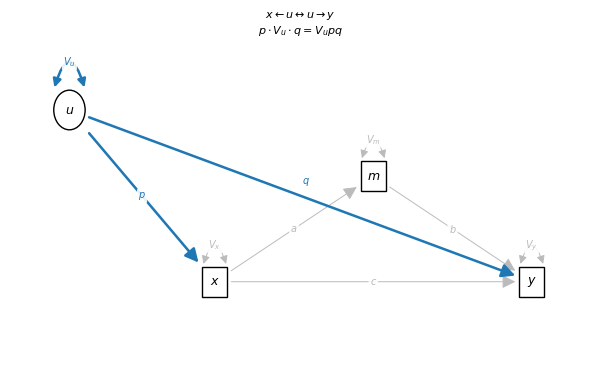

In [10]:
confounding = [c for c in decomposition.sorted_chains() if c.path_string() == "x <- u <-> u -> y"][0]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
draw_on_axes(m, ax, layout=layout, style=DiagramStyle(), highlight=confounding)
plt.show()

### Why there are two engines

Both engines now answer the same question. That they agree is the property the whole test suite is
built around — every model in the shared battery is checked both ways, because the two routes share
no code.

In [11]:
gap = sp.simplify(engine.cov("x", "y") - tracer.cov("x", "y"))
display(Markdown(
    f"`RAMEngine` minus `WrightTracer`, simplified: **`{gap}`** — "
    f"across **{len(decomposition)}** chains."
))

`RAMEngine` minus `WrightTracer`, simplified: **`0`** — across **5** chains.

They are not redundant, though. Each can do something the other cannot:

- **the tracer** gives the *decomposition*; the RAM engine only ever gives a total.
- **the RAM engine** handles **cycles**. $(I-A)^{-1}$ sums feedback loops to convergence; chain
  enumeration would not terminate. It also scales better, because it builds $\Sigma$ once and
  caches it against `model.revision`, so further queries are matrix lookups.

Use the tracer when you want to understand or publish a result, the engine when you want the number.

### Latent variables are ordinary query targets

`u` is never observed. You can still ask about it — this is not an afterthought, it is most of why
a symbolic tool is useful: the quantity you want is usually the one you cannot measure.

In [12]:
print(tracer.trace("u", "y"))

Cov[u, y]  (3 chains, unstandardized)
  u <-> u -> y            =  V_u * q
  u <-> u -> x -> y       =  V_u * p * c
  u <-> u -> x -> m -> y  =  V_u * p * a * b
  total                   =  V_u*a*b*p + V_u*c*p + V_u*q


---
## Act 2 — co-paths, and the trap

Now a genuinely different kind of dependence. Two people mate **assortatively**: they resemble each
other because of how they paired up, not because either causes the other and not because of a
shared cause.

Each partner has $y = g + e$, a genetic and an environmental component. Their phenotypes correlate
at $\rho_y$.

The obvious encoding is a bidirected edge between the phenotypes. Watch it fail.

In [13]:
wrong = pm.from_text(
    '''
    latent: g_m, e_m, g_p, e_p
    positive: V_A, V_E
    y_m ~ g_m + e_m
    y_p ~ g_p + e_p
    g_m ~~ V_A*g_m
    e_m ~~ V_E*e_m
    g_p ~~ V_A*g_p
    e_p ~~ V_E*e_p
    y_m ~~ (rho_y*(V_A + V_E))*y_p
    ''',
    name="assortment as a bidirected edge (WRONG)",
)

for issue in wrong.validate():
    print(f"[{issue.severity}] {issue.message}")

[error] 'y_m' is endogenous with no disturbance variance, so its disturbance is identically zero and cannot covary with 'y_p' -- yet 'y_m <-> y_p' says it does. The implied covariance matrix is not positive semi-definite. Bidirected edges are DISTURBANCE covariances: to correlate a variable that has parents, add the association as a directed path, or give 'y_m' a disturbance variance.
[error] 'y_p' is endogenous with no disturbance variance, so its disturbance is identically zero and cannot covary with 'y_m' -- yet 'y_m <-> y_p' says it does. The implied covariance matrix is not positive semi-definite. Bidirected edges are DISTURBANCE covariances: to correlate a variable that has parents, add the association as a directed path, or give 'y_p' a disturbance variance.


`validate()` rejects it, and the reason is worth having straight: **a bidirected edge is a
covariance between *disturbances*, not between variables.** `y_m` is endogenous — fully determined
by `g_m + e_m` — so its disturbance is identically zero, and declaring that a zero covaries with
something is not a statement about the world. Left in, it produces a $\Sigma$ that is not positive
semi-definite: an implied correlation above 1, with nothing to signal it.

Suppose we ignore the warning. The second failure is quieter and worse.

In [14]:
wrong_engine = pm.RAMEngine(wrong)
display(Markdown(
    f"- $\\operatorname{{Cov}}[y_m, y_p] = {sp.latex(sp.factor(wrong_engine.cov('y_m', 'y_p')))}$ "
    "— the phenotypic covariance we asked for, so this looks like it worked.\n"
    f"- $\\operatorname{{Cov}}[g_m, g_p] = {sp.latex(wrong_engine.cov('g_m', 'g_p'))}$ "
    "— and this is the failure."
))

- $\operatorname{Cov}[y_m, y_p] = \rho_{y} \left(V_{A} + V_{E}\right)$ — the phenotypic covariance we asked for, so this looks like it worked.
- $\operatorname{Cov}[g_m, g_p] = 0$ — and this is the failure.

Their **genetic values are uncorrelated**. That is false, and it is the whole point of assortative
mating: partners who resemble each other phenotypically resemble each other genetically, which is
why assortment changes the genetic variance of the *next* generation. A bidirected edge cannot
produce it, because association across a bidirected edge does not propagate **backward to the
causes** of the variables it joins.

### The co-path

So there is a third edge type. A **co-path** is covariance attributable to *matching*: it induces
covariance without causing variance, and it does propagate backward into the causes. Its
coefficient is not the correlation — $\operatorname{Cov}[a,b] = \mu \operatorname{Var}[a]
\operatorname{Var}[b]$, so a target correlation $\rho_y$ needs $\mu = \rho_y / V_P$.

In the text syntax it is `--`. One edge, replacing everything the bidirected version got wrong.

In [15]:
pair = pm.from_text(
    '''
    latent: g_m, e_m, g_p, e_p
    positive: V_A, V_E
    y_m ~ g_m + e_m
    y_p ~ g_p + e_p
    g_m ~~ V_A*g_m
    e_m ~~ V_E*e_m
    g_p ~~ V_A*g_p
    e_p ~~ V_E*e_p
    y_m -- [rho_y]*y_p
    ''',
    name="assortment as a co-path",
)
print("validation issues:", [i.severity for i in pair.validate()] or "none")

pair_engine = pm.RAMEngine(pair)
V_A, V_E, rho_y = (pair.sym(s) for s in ("V_A", "V_E", "rho_y"))
V_P = V_A + V_E

sp.Matrix([[sp.Symbol(rf"\operatorname{{Cov}}[{a},{b}]"), sp.factor(pair_engine.cov(a, b))]
           for a, b in [("y_m", "y_p"), ("g_m", "g_p"), ("e_m", "g_p"), ("e_m", "e_p")]])

validation issues: none


⎡\operatorname{Cov}[y_m,y_p]  ρ_y⋅(V_A + V_E)⎤
⎢                                            ⎥
⎢                                   2        ⎥
⎢                                V_A ⋅ρ_y    ⎥
⎢\operatorname{Cov}[g_m,g_p]     ─────────   ⎥
⎢                                V_A + V_E   ⎥
⎢                                            ⎥
⎢                               V_A⋅V_E⋅ρ_y  ⎥
⎢\operatorname{Cov}[e_m,g_p]    ───────────  ⎥
⎢                                V_A + V_E   ⎥
⎢                                            ⎥
⎢                                   2        ⎥
⎢                                V_E ⋅ρ_y    ⎥
⎢\operatorname{Cov}[e_m,e_p]     ─────────   ⎥
⎣                                V_A + V_E   ⎦

**None of the last three were specified.** One co-path on the phenotypes induces covariance among
*all* the causes, which is what makes it the right primitive: assortment is one fact about how
people pair, not four separate covariance assumptions.

Two checks that it is doing the right thing:

In [16]:
rho_g = rho_y * V_A / V_P

checks = {
    r"\operatorname{Cov}[y_m,y_p] = \rho_y V_P": pair_engine.cov("y_m", "y_p") - rho_y * V_P,
    r"\operatorname{Cov}[g_m,g_p] = \rho_g V_A": pair_engine.cov("g_m", "g_p") - rho_g * V_A,
    r"\operatorname{Cov}[e_m,g_p] = \rho_g V_E": pair_engine.cov("e_m", "g_p") - rho_g * V_E,
}
for claim, residual in checks.items():
    display(Math(claim + r"\quad\Longrightarrow\quad " + sp.latex(sp.simplify(residual))))

# "induces covariance without causing variance" -- Sunde's defining phrase, checked
without = pair.copy()
without.remove_copath("y_m", "y_p")
plain = pm.RAMEngine(without)
unchanged = all(sp.simplify(pair_engine.var(n) - plain.var(n)) == 0 for n in pair.names)
display(Markdown(f"every variance unchanged by adding the co-path: **{unchanged}**"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

every variance unchanged by adding the co-path: **True**

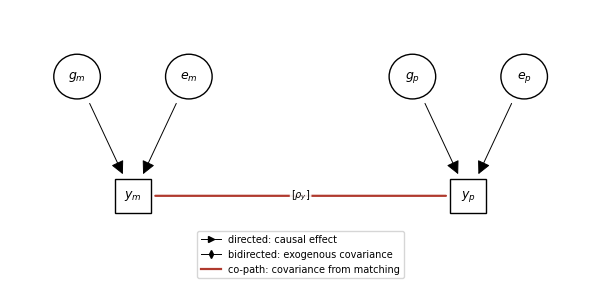

In [17]:
pair_layout = Layout({
    "g_m": (0.0, 1.6), "e_m": (1.5, 1.6), "y_m": (0.75, 0.0),
    "g_p": (4.5, 1.6), "e_p": (6.0, 1.6), "y_p": (5.25, 0.0),
})
fig, ax = plt.subplots(figsize=(7.5, 4.0))
draw_on_axes(pair, ax, layout=pair_layout, style=DiagramStyle(show_variances=False), legend=True)
plt.show()

The co-path is the flat line with **no arrowheads** — the absence is the notation: nothing is
causing anything.

This is the most expensive lesson in the project, and there is a longer write-up of it in
[`docs/assortment_representation_trap.md`](../docs/assortment_representation_trap.md), including
why the bidirected encoding is nonetheless *correct* for a founding couple, where both partners are
exogenous.

---
## Act 3 — a pedigree under assortative mating

Now use it where you could not check it by hand. `am_pedigree` builds the structure — a founding
couple, then each generation one child takes an outside partner and reproduces — and
`g_level_model` turns that into a path model, with **one co-path per couple**.

In [18]:
from pathmgr.genetics import am_pedigree, g_level_model

pedigree = am_pedigree(2, children_per_couple=2, breeding_children=1, half_sib_at=0)
unrolled = g_level_model(pedigree)
model = unrolled.model

display(Markdown(
    f"**{len(pedigree.individuals)} individuals** in {pedigree.n_generations} generations, "
    f"**{len(pedigree.couples)} couples** → a model with **{len(model.names)} variables**, "
    f"**{len(model.directed_edges)} directed edges** and "
    f"**{len(model.copaths)} co-paths**."
))

**9 individuals** in 3 generations, **3 couples** → a model with **32 variables**, **33 directed edges** and **3 co-paths**.

`half_sib_at=0` gives one founder a second partner and a child by them, which buys two of the four
results below.

The co-path coefficient is **generation-indexed**, and this is the second half of the trap in Act 2.
Assortment increases the phenotypic variance every generation, so holding the partner *correlation*
$\rho_y$ fixed means $\mu_t = \rho_y / V_P(t)$ differs at every generation — and a coefficient copied
from one generation to the next is quietly wrong.

**Which is why nothing here writes it.** The pedigree declares each co-path by the correlation
(`correlation=rho_y`, the `[\rho_y]` you saw in Act 2) and the engines derive $\mu_t$ themselves,
resolving co-paths in dependency order so each is computed against the variances that actually
obtain at its own depth. The values below are what that resolves to — reported, not supplied.

In [19]:
sp.Matrix([[sp.Symbol(f"\\mu_{t}"), unrolled.mu[t]] for t in range(len(unrolled.mu))])

⎡         ρ_y     ⎤
⎢\mu₀  ────────── ⎥
⎢      V_A0 + V_E ⎥
⎢                 ⎥
⎢          ρ_y    ⎥
⎢\mu₁  ───────────⎥
⎢      V_A_1 + V_E⎥
⎢                 ⎥
⎢          ρ_y    ⎥
⎢\mu₂  ───────────⎥
⎣      V_A_2 + V_E⎦

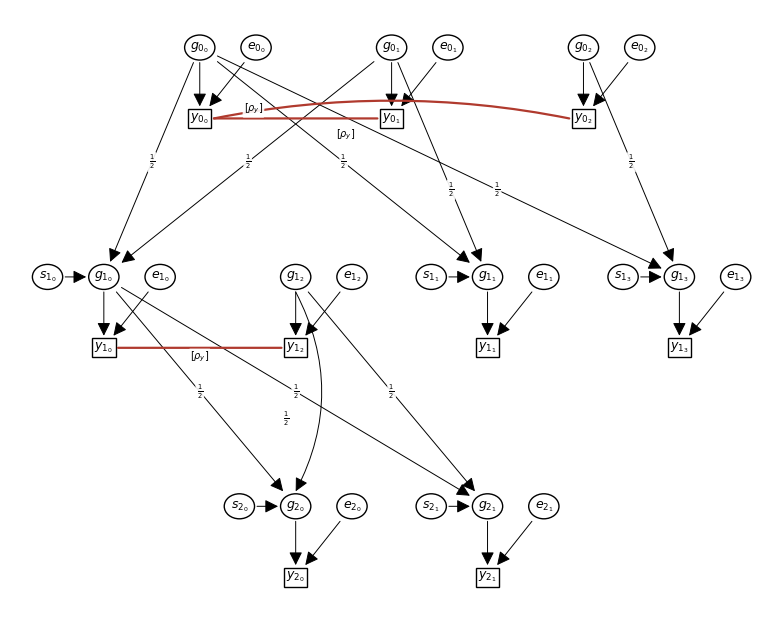

In [20]:
fig, ax = plt.subplots(figsize=(13, 8))
draw_on_axes(model, ax, layout=unrolled.layout(),
             style=DiagramStyle(show_variances=False))
plt.show()

Every individual is a block: `g` (genetic) and `e` (environment) feeding `y` (phenotype), plus `s`
(segregation) for anyone with parents. Transmission is the two `1/2` arrows from each parent's `g`.
The red arrowless lines between partners are the co-paths.

### Four results that are worth the tool

Now the queries. These are chosen because the answers are **not** what the textbook formulas
suggest, and each one took a hand derivation to trust.

In [21]:
founder_maternal = pedigree.couples[0].maternal
children = sorted(pedigree.children_of(pedigree.couples[0]))
grandchild = sorted(pedigree.children_of(pedigree.couples[1]))[0]

e_ped = pm.RAMEngine(model)
V_A0, V_E_s, rho_y_s = unrolled.V_A0, unrolled.V_E, unrolled.rho_y

# indexed to the PARENTS' generation, which is the index that matters
rho_g0, rho_g1 = unrolled.rho_g[0], unrolled.rho_g[1]

parent_offspring = e_ped.cov(f"y_{founder_maternal}", f"y_{children[0]}")
full_sibs = e_ped.cov(f"y_{children[0]}", f"y_{children[1]}")

display(Math(r"\text{parent–offspring:}\quad " + sp.latex(sp.factor(parent_offspring))))
display(Math(r"\text{full siblings:}\quad " + sp.latex(sp.factor(full_sibs))))

# the same two, written with rho_g and rho_y made explicit, and their difference
V_A_0 = unrolled.V_A[0]
display(Math(r"\text{parent–offspring} = \tfrac{1}{2} V_A(0)(1 + \rho_y):\quad " +
             sp.latex(sp.simplify(parent_offspring - V_A_0 * (1 + rho_y_s) / 2))))
display(Math(r"\text{full siblings} = \tfrac{1}{2} V_A(0)(1 + \rho_g(0)):\quad " +
             sp.latex(sp.simplify(full_sibs - V_A_0 * (1 + rho_g0) / 2))))
display(Math(r"\text{difference} = \tfrac{1}{2} V_A(0)(\rho_y - \rho_g(0)):\quad " +
             sp.latex(sp.simplify(parent_offspring - full_sibs - V_A_0 * (rho_y_s - rho_g0) / 2))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**1. Same degree, different answers.** Parent–offspring and full siblings are both first-degree
relatives, and under random mating both are $V_A/2$. Under assortment they separate: the parent–
offspring covariance carries $\rho_y$, the sibling covariance carries $\rho_g$. Since
$\rho_g = \rho_y h^2 < \rho_y$ the parent–offspring covariance is the larger of the two, by the
amount the third line computes. Under random mating both collapse to $V_A/2$ and the distinction
disappears entirely.

In [22]:
lineal_d2 = e_ped.cov(f"y_{founder_maternal}", f"y_{grandchild}")       # grandparent–grandchild
collateral_d2 = e_ped.cov(f"y_{children[1]}", f"y_{grandchild}")      # avuncular

display(Math(r"\text{grandparent–grandchild:}\quad " + sp.latex(sp.factor(lineal_d2))))
display(Math(r"\text{avuncular:}\quad " + sp.latex(sp.factor(collateral_d2))))
display(Math(r"\text{difference:}\quad " +
             sp.latex(sp.factor(sp.simplify(lineal_d2 - collateral_d2)))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**2. And at the same degree *two* steps out, the split has a specific source.** Both pairs are
second-degree. They differ, and the difference is proportional to $V_E$ — so it is not a genetic
effect at all. Check that directly by asking the same question about the genetic values instead of
the phenotypes:

In [23]:
g_gap = sp.simplify(e_ped.cov(f"g_{founder_maternal}", f"g_{grandchild}")
                    - e_ped.cov(f"g_{children[1]}", f"g_{grandchild}"))
display(Markdown(
    f"At the **genetic** level the same two pairs differ by `{g_gap}` — they are *identical*. "
    "The lineal/collateral asymmetry is entirely a phenotype-level phenomenon, carried by "
    r"$\operatorname{Cov}[e_{\text{partner}}, g_{\text{focal}}] = \rho_g V_E$: assortment on the "
    "phenotype correlates one partner's *environment* with the other's *genes*, and only a "
    "phenotypic query can see it."
))

At the **genetic** level the same two pairs differ by `0` — they are *identical*. The lineal/collateral asymmetry is entirely a phenotype-level phenomenon, carried by $\operatorname{Cov}[e_{\text{partner}}, g_{\text{focal}}] = \rho_g V_E$: assortment on the phenotype correlates one partner's *environment* with the other's *genes*, and only a phenotypic query can see it.

In [24]:
half_sibling = sorted(pedigree.children_of(pedigree.couples[2]))[0]
print("relationship:", pedigree.relationship(children[0], half_sibling))

half = e_ped.cov(f"g_{children[0]}", f"g_{half_sibling}")
V_A_t, V_P_t = unrolled.V_A[0], unrolled.V_P[0]
collateral_formula = V_A_t * (1 + rho_g0) ** 2 / 4

display(Math(r"\text{half siblings:}\quad " + sp.latex(sp.factor(half))))
display(Math(r"\text{minus the collateral degree-2 formula:}\quad " +
             sp.latex(sp.factor(sp.simplify(half - collateral_formula)))))
display(Math(r"\text{...which is exactly } \rho_g(0)^2 V_E / 4:\quad " +
             sp.latex(sp.simplify(half - collateral_formula - rho_g0**2 * V_E_s / 4))))

relationship: half siblings


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**3. Half-siblings follow neither formula.** They exceed the collateral form by exactly
$\rho_g^2 V_E / 4$. A half-sib chain has to cross co-paths belonging to **two different mating
processes** — their shared parent mated twice — and that is a case the closed-form relative
formulas simply do not cover. It is also the sharpest test that the co-path rules are implemented
right: at most one co-path per mating process per chain, but *different* processes are free.

In [25]:
outer_a, outer_b = pedigree.couples[0].paternal, pedigree.couples[2].paternal
shared = pedigree.ancestors_of(outer_a) & pedigree.ancestors_of(outer_b)

correlated = e_ped.cov(f"g_{outer_a}", f"g_{outer_b}")
display(Markdown(f"common ancestors of the two outside partners: **{shared or 'none'}**"))
display(Math(r"\operatorname{Cov}[g_a, g_b] = " + sp.latex(sp.factor(correlated))))
display(Math(r"\text{which is } \rho_g(0)^2 V_P(0):\quad " +
             sp.latex(sp.simplify(correlated - rho_g0**2 * unrolled.V_P[0]))))
display(Math(r"\text{at } \rho_y = 0:\quad " +
             sp.latex(sp.simplify(correlated.subs({rho_y_s: 0})))))

common ancestors of the two outside partners: **none**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**4. Two people with no common ancestor, genetically correlated.** They each had a child with the
same third person and are otherwise unrelated — no shared ancestry whatsoever — and yet
$\operatorname{Cov} = \rho_g^2 V_P$. Under random mating it is exactly zero, as the last line
confirms. Assortment makes "unrelated" a much narrower category than it sounds, and no
relatedness-by-descent calculation will find this term.

### Dynamics

The genetic variance grows each generation, because assorting parents produce offspring more
variable than random pairing would. Iterating the recursion the engine implies:

### Reading those results in the usual notation

Everything above is written in the base parameters, which is honest and hard to read. A statistical
geneticist writes these with two derived quantities: the phenotypic variance
$V_P(t) = V_A(t) + V_E$, and $\rho_g(t) = \rho_y V_A(t)/V_P(t)$, the genetic correlation between
partners. `unrolled.compact()` rewrites a result in those terms.

It is strictly a **display** step — `cov()` keeps returning the general expression, and every
candidate is checked by substituting the definitions back before it is returned, so compaction can
decline to shorten but cannot alter a value.

In [26]:
compacted = {
    "parent–offspring": parent_offspring,
    "full siblings": full_sibs,
    "grandparent–grandchild": lineal_d2,
    "avuncular": collateral_d2,
}
for label, expression in compacted.items():
    display(Math(rf"\text{{{label}:}}\quad " + sp.latex(unrolled.compact(expression))))

display(Markdown(
    f"*{unrolled.explain_compaction()}.* The sibling and avuncular forms are now exactly what the "
    "writeup states — and the contrast from result 1 is visible at a glance: parent–offspring "
    r"carries $\rho_y$ where full siblings carry $\rho_g(0)$."
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

*compacted with V_P(t) = V_A(t) + V_E and rho_g(t) = rho_y V_A(t)/V_P(t).* The sibling and avuncular forms are now exactly what the writeup states — and the contrast from result 1 is visible at a glance: parent–offspring carries $\rho_y$ where full siblings carry $\rho_g(0)$.

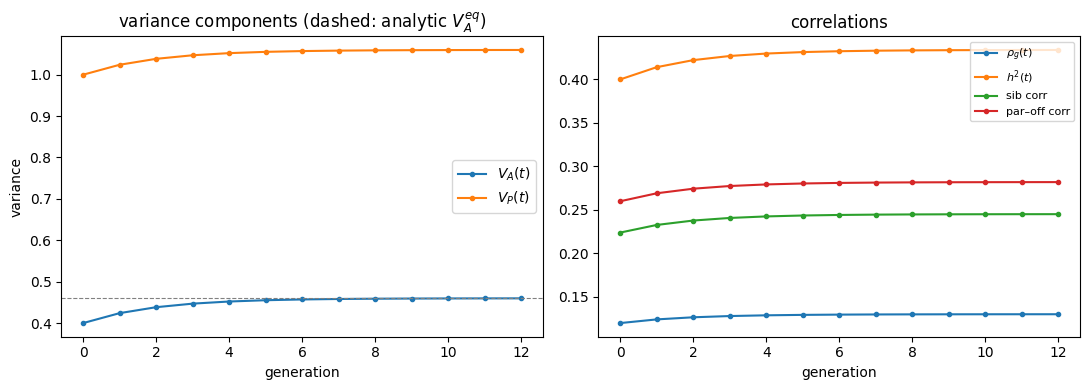

`generations_to_converge(0.01)` = **6**, consistent with the six-to-ten generations reported in the literature. `plot_trajectories(dynamics, path)` writes this figure to a file directly.

In [27]:
from pathmgr.genetics import AMDynamics

dynamics = AMDynamics(V_A0=0.4, V_E=0.6, rho_y=0.3)   # the writeup's worked example
trajectory = dynamics.trajectory(n_generations=12)
fixed_point = dynamics.equilibrium()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for key, label in [("V_A", r"$V_A(t)$"), ("V_P", r"$V_P(t)$")]:
    axes[0].plot(trajectory["generation"], trajectory[key], marker="o", ms=3, label=label)
axes[0].axhline(fixed_point["V_A"], ls="--", lw=0.8, color="grey")
axes[0].set_xlabel("generation"); axes[0].set_ylabel("variance"); axes[0].legend()
axes[0].set_title("variance components (dashed: analytic $V_A^{eq}$)")

for key, label in [("rho_g", r"$\rho_g(t)$"), ("h2", r"$h^2(t)$"),
                   ("sibling_corr", "sib corr"), ("parent_offspring_corr", "par–off corr")]:
    axes[1].plot(trajectory["generation"], trajectory[key], marker="o", ms=3, label=label)
axes[1].set_xlabel("generation"); axes[1].legend(fontsize=8)
axes[1].set_title("correlations")
plt.tight_layout(); plt.show()

display(Markdown(
    f"`generations_to_converge(0.01)` = **{dynamics.generations_to_converge(0.01)}**, "
    "consistent with the six-to-ten generations reported in the literature. "
    "`plot_trajectories(dynamics, path)` writes this figure to a file directly."
))

### The equilibrium, solved rather than quoted

Unrolling generations is not how you find the fixed point. `equilibrium()` sets
$V_A(t{+}1) = V_A(t)$ in the recursion **the engine implies**, closes the loop through
$\rho_g = \rho_y h^2_{eq}$, and solves — so the quadratic below is *derived*, not transcribed from
a paper.

In [28]:
from pathmgr.genetics import equilibrium

eq = equilibrium()
display(Math(r"\text{the quadratic in } \rho_g:\quad " + sp.latex(eq.quadratic)))
display(Math(r"\rho_g^{eq} = " + sp.latex(eq.rho_g)))
display(Math(r"V_A^{eq} = " + sp.latex(eq.V_A) + r"\qquad h^2_{eq} = " + sp.latex(eq.h2)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [29]:
worked = eq.evaluate({"V_A0": 0.4, "V_E": 0.6, "rho_y": 0.3})
unrolled_V_A = dynamics.V_A(60)[-1]

display(Markdown(
    "**The writeup's worked example**, $V_A^{(0)} = 0.4$, $V_E = 0.6$, $\\rho_y = 0.3$:\n\n"
    + "\n".join(f"- ${k}$ = **{v:.6f}**" for k, v in
                [("\\rho_g^{eq}", worked["rho_g"]), ("V_A^{eq}", worked["V_A"]),
                 ("V_P^{eq}", worked["V_P"]), ("h^2_{eq}", worked["h2"])])
    + f"\n\nand unrolling the recursion 60 generations numerically lands at "
      f"$V_A$ = **{unrolled_V_A:.6f}**, agreeing with the solved value to "
      f"**{abs(unrolled_V_A - worked['V_A']):.1e}**."
))

**The writeup's worked example**, $V_A^{(0)} = 0.4$, $V_E = 0.6$, $\rho_y = 0.3$:

- $\rho_g^{eq}$ = **0.130166**
- $V_A^{eq}$ = **0.459858**
- $V_P^{eq}$ = **1.059858**
- $h^2_{eq}$ = **0.433886**

and unrolling the recursion 60 generations numerically lands at $V_A$ = **0.459858**, agreeing with the solved value to **3.4e-15**.

### One more thing, and it is the most important cell in this notebook

Those parameters were chosen so that $V_A^{(0)} + V_E = 1$, i.e. $V_P(0) = 1$. That is the
writeup's convention and it is harmless *there* — but if it is the only case you ever see, you will
internalise formulas that only hold in it. In this project that masking hid **three separate wrong
results**, because at $V_P = 1$ you cannot tell $V_A$ from $h^2$, or $\rho_y$ from $\rho_y V_P$.

`equilibrium()` keeps the $V_P(0)=1$ form around as `writeup_quadratic`, precisely so the two can
be compared. Move off $V_P(0)=1$ and they part company.

In [30]:
off_unit = {"V_A0": 0.5, "V_E": 0.8, "rho_y": 0.3}     # V_P(0) = 1.3
rho_g_symbol = eq.symbols["rho_g"]
substituted = eq.substitute(off_unit)

def smallest_root(expression):
    roots = [r for r in sp.solve(expression, rho_g_symbol) if r.is_real and 0 <= r < 1]
    return min(roots)

general = smallest_root(substituted.quadratic)
writeup = smallest_root(substituted.writeup_quadratic)

display(Math(r"\text{general:}\quad " + sp.latex(substituted.quadratic) +
             r"\quad\Rightarrow\quad \rho_g = " + sp.latex(general)))
display(Math(r"\text{writeup } (V_P(0)=1)\text{:}\quad " + sp.latex(substituted.writeup_quadratic) +
             r"\quad\Rightarrow\quad \rho_g = " + sp.latex(sp.nsimplify(writeup, rational=False))))

error = abs(float(writeup) - float(general)) / float(general)
display(Markdown(
    f"At $V_P(0) = {off_unit['V_A0'] + off_unit['V_E']}$ the general form gives "
    f"$\\rho_g = {float(general):.6f}$ and the writeup's form gives {float(writeup):.6f} — "
    f"an error of **{error:.0%}**. At $V_P(0) = 1$ the two agree exactly; here they do not, and "
    "nothing about the writeup's quadratic announces the assumption. "
    "**Never choose test parameters that sum to 1.**"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

At $V_P(0) = 1.3$ the general form gives $\rho_g = 0.125000$ and the writeup's form gives 0.163340 — an error of **31%**. At $V_P(0) = 1$ the two agree exactly; here they do not, and nothing about the writeup's quadratic announces the assumption. **Never choose test parameters that sum to 1.**

In [31]:
# and the general form still checks out where the special case does apply
at_unit = eq.substitute({"V_A0": 0.4, "V_E": 0.6, "rho_y": 0.3})
display(Markdown(
    "the two quadratics at $V_P(0) = 1$: "
    f"**{sp.simplify(at_unit.quadratic.lhs - at_unit.writeup_quadratic.lhs) == 0}**"
))

the two quadratics at $V_P(0) = 1$: **True**

---
## Act 4 — getting a figure into your document

The render layer has two back ends off the same style conventions: matplotlib (everything above)
and **TikZ**, for a LaTeX writeup.

In [32]:
from pathmgr.render import to_tikz

snippet = to_tikz(pair, layout=pair_layout, style=DiagramStyle.portable(show_variances=False))
print(snippet[:700] + "\n...")

\definecolor{pmCB03A2E}{HTML}{B03A2E}
\begin{tikzpicture}[
  every node/.style={font=\small},
  pmObserved/.style={draw=black, fill=white, rectangle, inner sep=0.06cm, minimum width=0.38cm, minimum height=0.34cm},
  pmLatent/.style={draw=black, fill=white, ellipse, inner xsep=0.07cm, inner ysep=0.13cm, minimum width=0.38cm, minimum height=0.34cm},
  pmDirected/.style={->, line width=0.7pt},
  pmBidirected/.style={<->, line width=0.7pt},
  pmCopath/.style={line width=1.6pt},
  pmLabel/.style={midway, fill=white, inner sep=1pt},
]
  \node[pmLatent] (g_m) at (0.000,1.600) {$g_{m}$};
  \node[pmLatent] (e_m) at (1.500,1.600) {$e_{m}$};
  \node[pmLatent] (g_p) at (4.500,1.600) {$g_{p}$};
  \node[p
...


To use it, paste the snippet into your document, or `\input` the file, with `tikz` loaded:

```latex
\usepackage{tikz}
\usetikzlibrary{arrows.meta, positioning}
```

`DiagramStyle.portable()` sticks to built-in arrow tips for preambles without `arrows.meta`.
`write_pdf` compiles a standalone PDF if `pdflatex` is available, and `to_image` writes
`.png` / `.svg` / `.pdf` through matplotlib with no LaTeX at all.

In [33]:
import shutil
import tempfile
from pathlib import Path

from pathmgr.render import to_image, write_pdf

scratch = Path(tempfile.mkdtemp())
png = to_image(pair, scratch / "mated_pair.png", layout=pair_layout,
               style=DiagramStyle(show_variances=False), dpi=150)
print(f"{png.name}: {png.stat().st_size // 1024} KB")

if shutil.which("pdflatex"):
    pdf = write_pdf(pair, scratch / "mated_pair.pdf", layout=pair_layout,
                    style=DiagramStyle.portable(show_variances=False))
    print(f"{pdf.name}: {pdf.stat().st_size // 1024} KB")
else:
    print("pdflatex not on PATH -- to_tikz and to_image still work")

shutil.rmtree(scratch)

mated_pair.png: 28 KB


mated_pair.pdf: 26 KB


---
## Where to go next

- **[`docs/assortment_representation_trap.md`](../docs/assortment_representation_trap.md)** — the
  longer version of Act 2. Read it before encoding assortment yourself.
- **`examples/spec_demo.py`** — a runnable tour of the whole API surface, wider than this notebook
  and with no narrative.
- **`examples/make_figures.py`** — produces `examples/figures/`, including the highlighted-chain
  figure, as `.tikz` + `.pdf` + `.png`.
- **`docs/scale_*.md`** — measured limits: how deep a pedigree, how many variants, how long
  $\Sigma$ takes.
- **`tests/battery.py`** — the shared model registry. Add a model there and the two-engine
  agreement sweep picks it up automatically, which is the cheapest way to check a new construction.
- **`CLAUDE.md`** — the conventions, and why each one is load-bearing.